# Validation: CPU (SciPy) vs JAX GPU Solver

This notebook runs the NEE solver with both the original SciPy CPU backend and the
JAX JIT-compiled GPU backend, comparing results side-by-side.

We walk up a **validation ladder** of increasing physical complexity,
verifying that the two solvers agree at each level.

In [1]:
import numpy as np
from numpy.fft import fft, ifft, fftshift, fftfreq
import matplotlib.pyplot as plt
import time

import snow.pulses as pulses
import snow.materials as materials
import snow.waveguides as waveguides

from scipy.constants import pi, c
nm = 1e-9
um = 1e-6
mm = 1e-3
ps = 1e-12
fs = 1e-15
MHz = 1e6
THz = 1e12
pJ = 1e-12
uW = 1e-6

plt.rcParams.update({'font.size': 14})

## Setup

Same grid and waveguide as Tutorial 5 (SHG).

In [2]:
# Time/Frequency grid
lam_start = 800*nm
lam_stop = 3*um
f_max = c/lam_start
f_min = c/lam_stop
BW = f_max - f_min
N = 2**10
dt = 1/BW
T = N/BW
t = -T/2 + np.arange(0, T, step=dt)
f = fftfreq(N, dt)
f_ref = (f_max + f_min)/2
f_abs = f + f_ref
wl = c/f_abs

# Waveguide
pp = 5.18*um

def make_waveguide(L, X0, alpha=0, poling_fn=None):
    wg = waveguides.waveguide(w_top=1800*nm, h_thinfilm=700*nm, h_etch=350*nm,
                              tf_material='LN_MgO_e', box_material='SiO2', clad_material='Air')
    if poling_fn is None:
        poling_fn = lambda z: np.sign(np.cos(z*2*pi/pp))
    wg.add_poling(poling_fn)
    wg.set_nonlinear_coeffs(N=1, X0=X0)
    wg.set_length(L)
    wg.set_loss(alpha)
    return wg

v_ref = 1/waveguides.waveguide(w_top=1800*nm, h_thinfilm=700*nm, h_etch=350*nm).beta1(1*um)
print(f'Grid: N={N}, BW={BW/THz:.1f} THz, dt={dt/fs:.2f} fs')

Grid: N=1024, BW=274.8 THz, dt=3.64 fs


## Helper: Run both backends and compare

In [3]:
def run_and_compare(title, pump, wg, v_ref=v_ref):
    """Run CPU and JAX, plot side-by-side using pulse convenience methods."""
    
    # CPU (SciPy)
    t0 = time.perf_counter()
    out_cpu, steps_cpu = wg.propagate_NEE(pump, v_ref=v_ref, verbose=False, backend='scipy')
    t_cpu = time.perf_counter() - t0
    
    # JAX GPU
    t0 = time.perf_counter()
    out_jax, steps_jax = wg.propagate_NEE(pump, v_ref=v_ref, verbose=False, backend='jax')
    t_jax = time.perf_counter() - t0
    
    # Field correlation
    corr = float(np.abs(np.sum(out_cpu.a * np.conj(out_jax.a))) /
                 np.sqrt(np.sum(np.abs(out_cpu.a)**2) * np.sum(np.abs(out_jax.a)**2)))
    
    # --- Row 1: Time domain and PSD using pulse convenience methods ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), tight_layout=True)
    fig.suptitle(f'{title}\nCorrelation = {corr:.6f} | '
                 f'CPU: {t_cpu:.2f}s ({len(steps_cpu)} steps) | '
                 f'JAX: {t_jax:.2f}s ({len(steps_jax)} steps)',
                 fontsize=13)
    
    # Time domain overlay (pulse.plot_magsq style)
    ax = axes[0, 0]
    pump.plot_magsq(ax=ax, t_unit='ps')
    out_cpu.plot_magsq(ax=ax, t_unit='ps')
    out_jax.plot_magsq(ax=ax, t_unit='ps')
    ax.get_lines()[-3].set(color='k', linestyle='--', alpha=0.3, label='Input')
    ax.get_lines()[-2].set(color='b', linewidth=1.5, label='CPU (SciPy)')
    ax.get_lines()[-1].set(color='r', linestyle='--', linewidth=1.5, label='JAX GPU')
    ax.legend(); ax.set_title('Temporal Intensity')
    
    # PSD overlay (pulse.plot_PSD style)
    ax = axes[0, 1]
    pump.plot_PSD(ax=ax, f_unit='um')
    out_cpu.plot_PSD(ax=ax, f_unit='um')
    out_jax.plot_PSD(ax=ax, f_unit='um')
    ax.get_lines()[-3].set(color='k', linestyle='--', alpha=0.3, label='Input')
    ax.get_lines()[-2].set(color='b', linewidth=1.5, label='CPU (SciPy)')
    ax.get_lines()[-1].set(color='r', linestyle='--', linewidth=1.5, label='JAX GPU')
    ax.legend(); ax.set_title('Power Spectral Density')
    
    # --- Row 2: Differences ---
    # Time domain difference
    ax = axes[1, 0]
    I_cpu = np.abs(out_cpu.a)**2
    I_jax = np.abs(out_jax.a)**2
    I_peak = max(np.max(I_cpu), np.max(I_jax))
    ax.plot(out_cpu.t/ps, (I_jax - I_cpu) / I_peak * 100)
    ax.set_xlabel('Time (ps)'); ax.set_ylabel('Difference (% of peak)')
    ax.set_title('Temporal Difference (JAX - CPU)'); ax.grid(True)
    
    # Spectral difference
    ax = axes[1, 1]
    spec_cpu = np.abs(fft(out_cpu.a))**2
    spec_jax = np.abs(fft(out_jax.a))**2
    spec_peak = max(np.max(spec_cpu), np.max(spec_jax))
    wl_plot = fftshift(c/f_abs)/um
    ax.plot(wl_plot, fftshift((spec_jax - spec_cpu) / spec_peak * 100))
    ax.set_xlabel('Wavelength (um)'); ax.set_ylabel('Difference (% of peak)')
    ax.set_title('Spectral Difference (JAX - CPU)'); ax.grid(True)
    
    plt.show()
    
    # Summary
    E_in = pump.energy_td()
    print(f'  Energy: in={E_in/pJ:.4f}  cpu={out_cpu.energy_td()/pJ:.4f}  '
          f'jax={out_jax.energy_td()/pJ:.4f} pJ')
    print(f'  Speedup: {t_cpu/t_jax:.1f}x')
    print()
    return corr

## Level 1: Linear propagation (no nonlinearity)

With X0=0, the pulse propagates linearly through the dispersive waveguide.
Both solvers should give identical results.

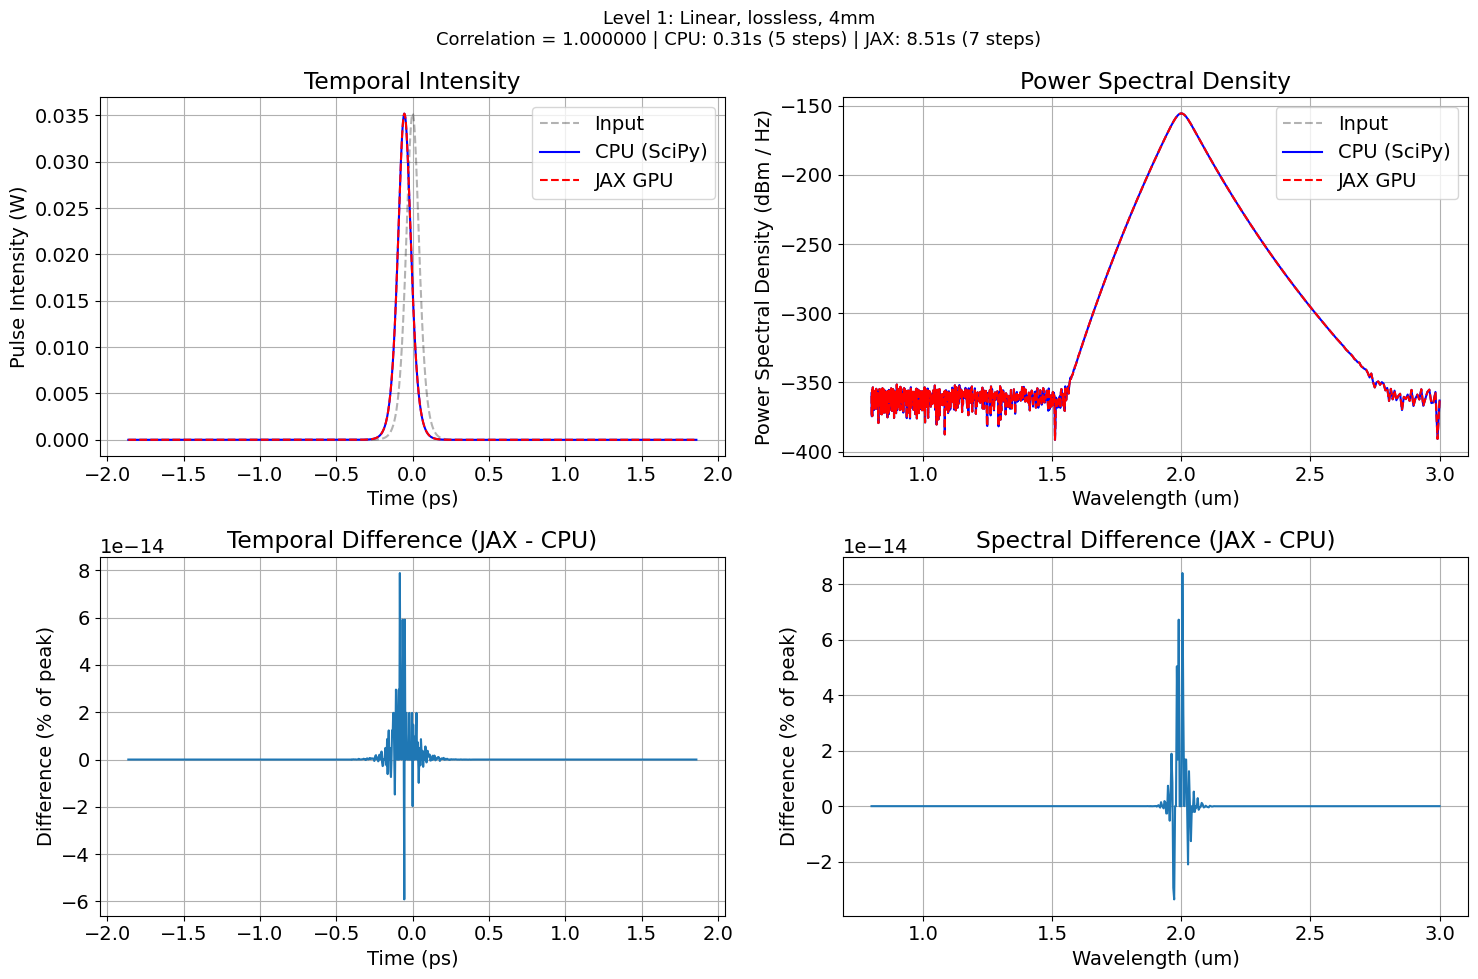

  Energy: in=0.0040  cpu=0.0040  jax=0.0040 pJ
  Speedup: 0.0x



In [4]:
pump = pulses.sech_pulse(t, 100*fs, Pavg=1*uW, f_ref=f_ref, f0=c/(2*um),
                         Npwr_dB=200, frep=250*MHz)
wg = make_waveguide(L=4*mm, X0=0)
run_and_compare('Level 1: Linear, lossless, 4mm', pump, wg);

## Level 2: Linear with loss

Add 0.5 dB/cm propagation loss. Output energy should be attenuated by exp(-alpha*L).

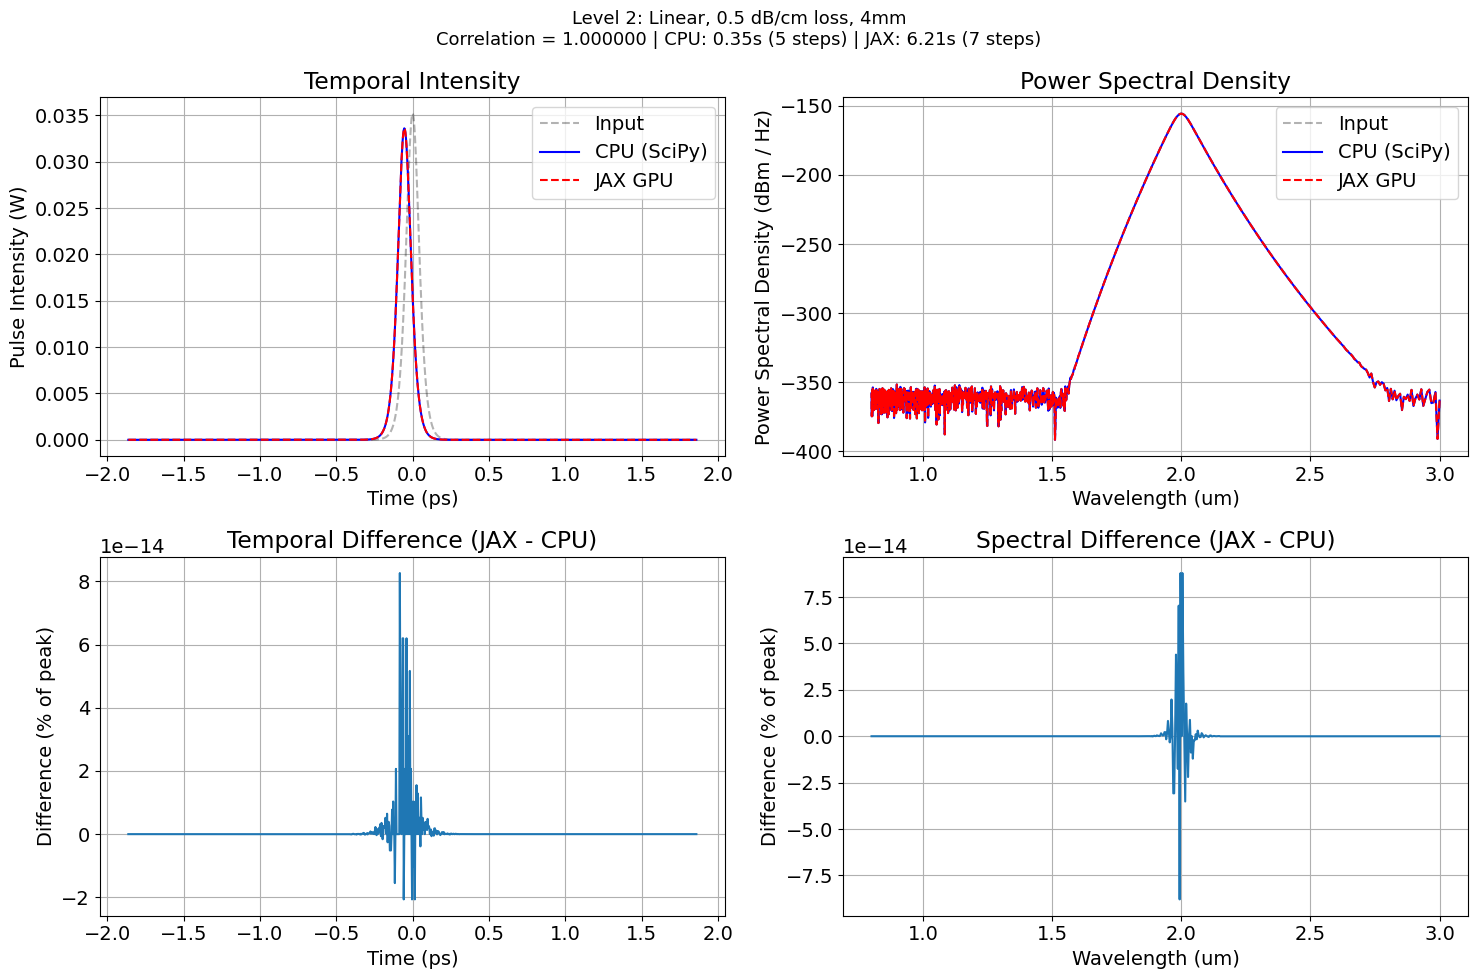

  Energy: in=0.0040  cpu=0.0038  jax=0.0038 pJ
  Speedup: 0.1x



In [5]:
from snow import util
alpha = util.absorption_coeff(0.5)
wg = make_waveguide(L=4*mm, X0=0, alpha=alpha)
run_and_compare('Level 2: Linear, 0.5 dB/cm loss, 4mm', pump, wg);

## Level 3: Weak SHG (uniform QPM)

Low-power SHG in a 4mm TFLN waveguide with 5.18 um poling period.
At 1 uW, we're deep in the undepleted-pump regime.

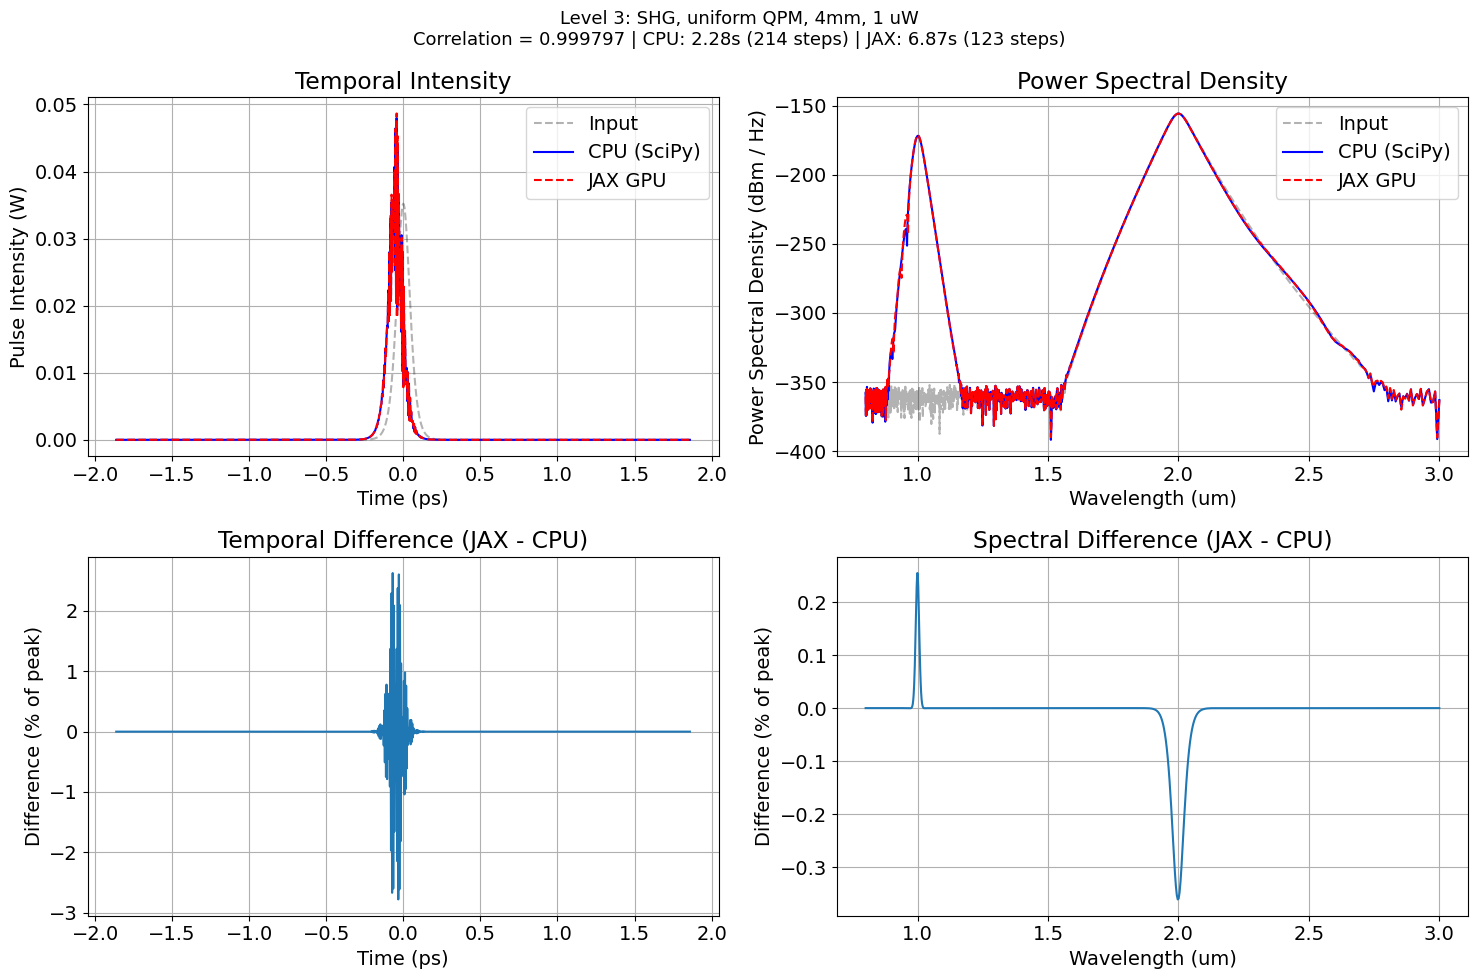

  Energy: in=0.0040  cpu=0.0040  jax=0.0040 pJ
  Speedup: 0.3x



In [6]:
wg = make_waveguide(L=4*mm, X0=1.1e-12)
run_and_compare('Level 3: SHG, uniform QPM, 4mm, 1 uW', pump, wg);

## Level 4: Chirped QPM

The poling period varies linearly with z, broadening the phase-matching bandwidth.
This tests that the z-dependent poling lookup table works correctly.

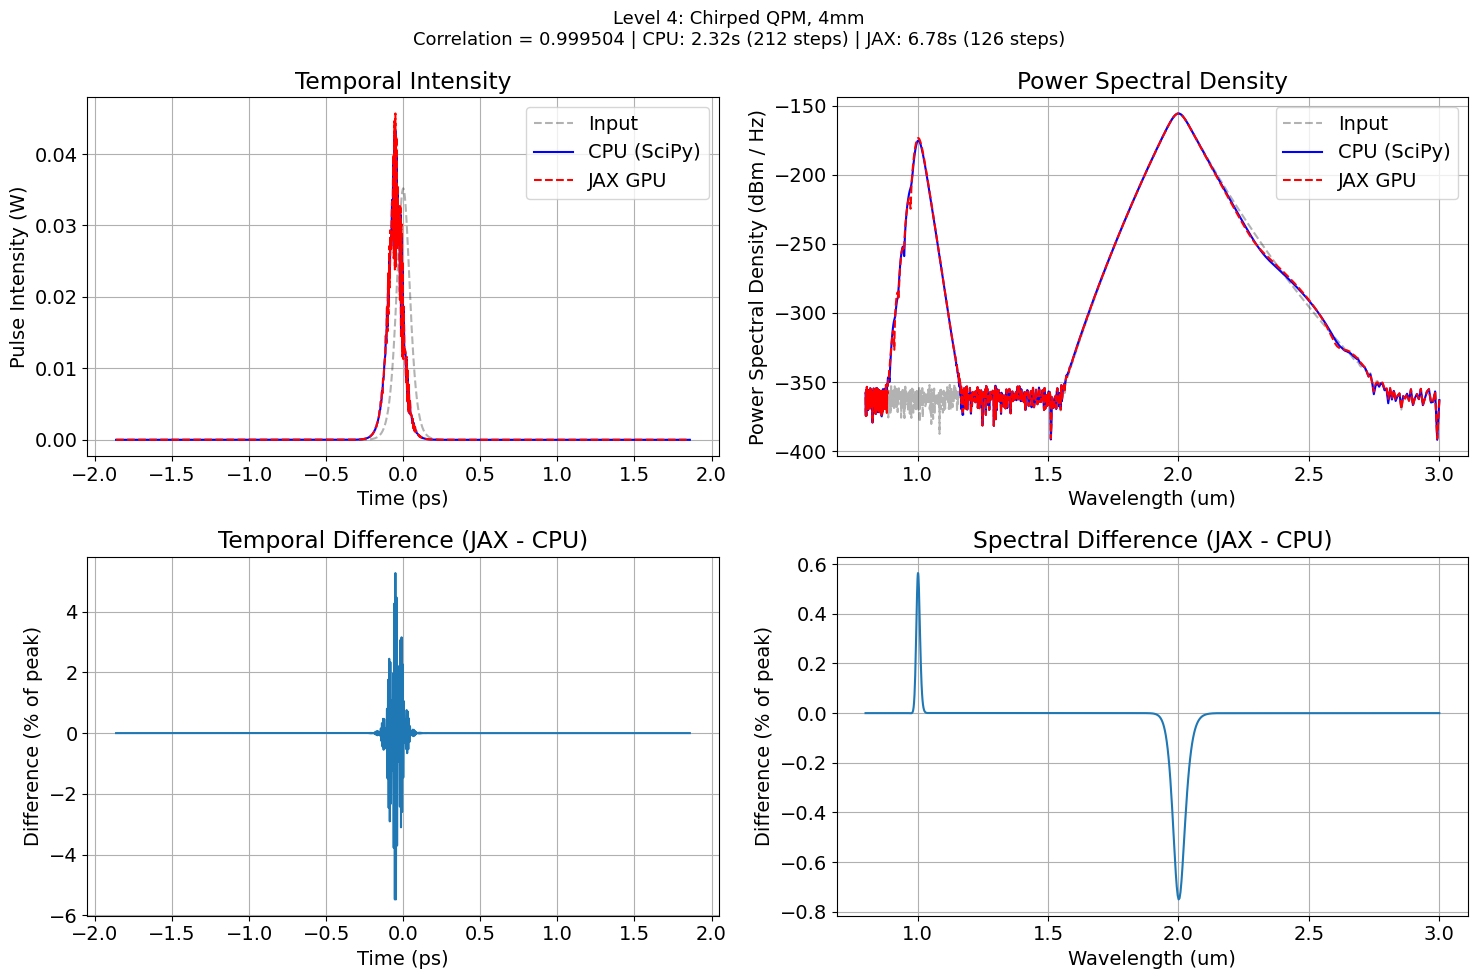

  Energy: in=0.0040  cpu=0.0040  jax=0.0040 pJ
  Speedup: 0.3x



In [7]:
chirp_rate = 0.5e-6  # period increases by 0.5 um per mm
poling_chirped = lambda z: np.sign(np.cos(z*2*pi/(pp + chirp_rate*z)))
wg = make_waveguide(L=4*mm, X0=1.1e-12, poling_fn=poling_chirped)
run_and_compare('Level 4: Chirped QPM, 4mm', pump, wg);

## Level 5: Apodized QPM

Gaussian-envelope poling suppresses the spectral sidelobes of the SHG.
Tests continuously-varying coupling strength.

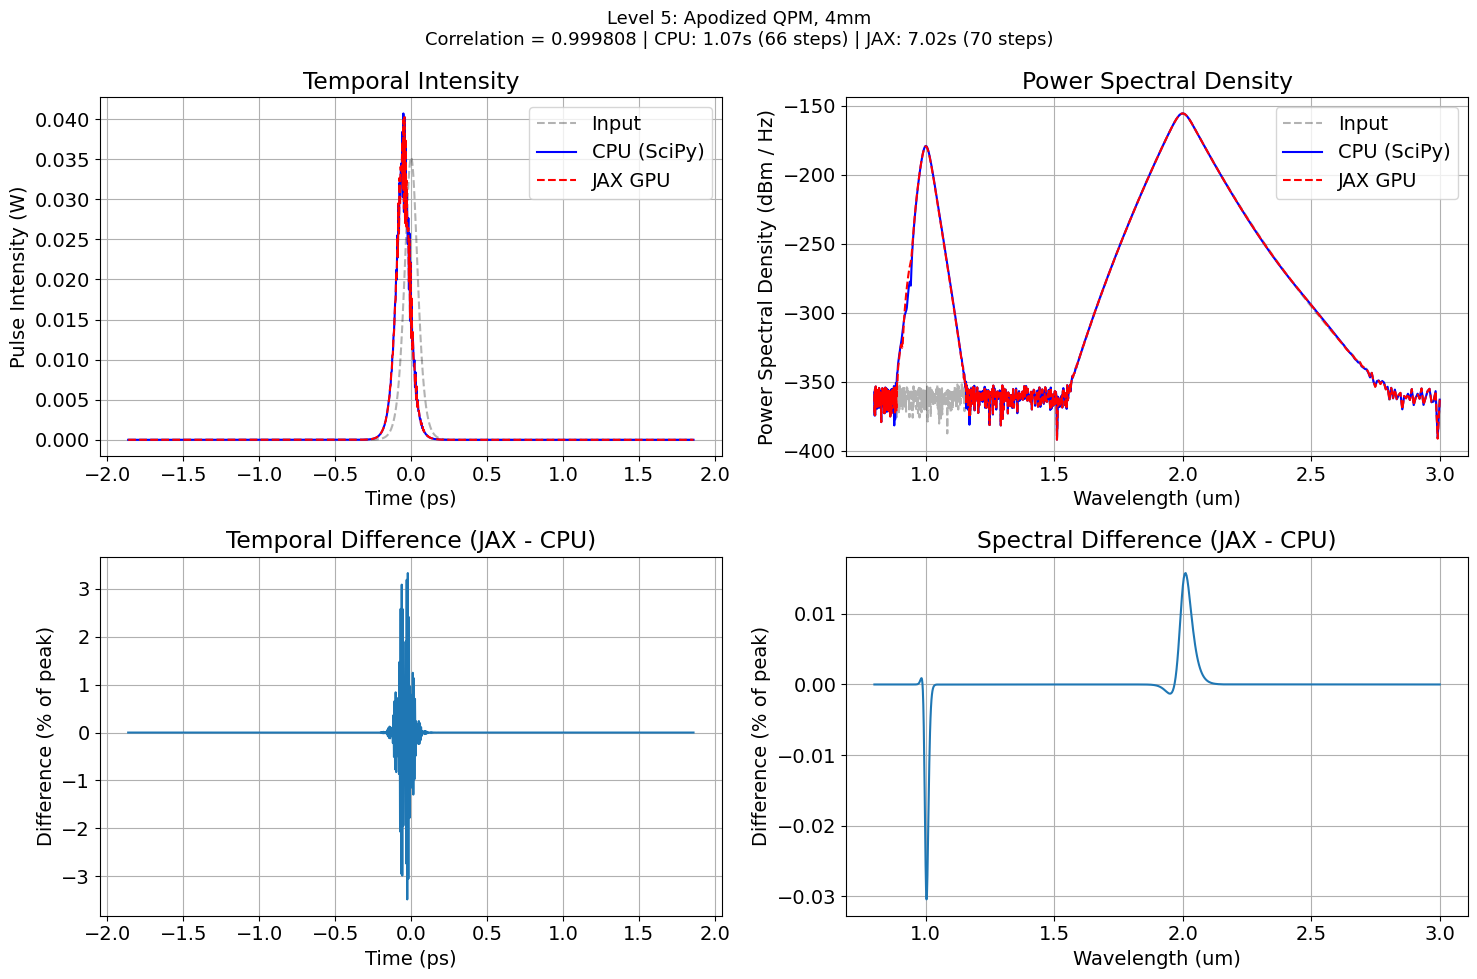

  Energy: in=0.0040  cpu=0.0040  jax=0.0040 pJ
  Speedup: 0.2x



In [8]:
L5 = 4*mm
poling_apod = lambda z: np.exp(-((z - L5/2)/(L5/4))**2) * np.sign(np.cos(z*2*pi/pp))
wg = make_waveguide(L=L5, X0=1.1e-12, poling_fn=poling_apod)
run_and_compare('Level 5: Apodized QPM, 4mm', pump, wg);

## Level 6: Longer crystal (10mm)

More propagation distance means more accumulated error between the solvers.
Tests stability over longer integration.

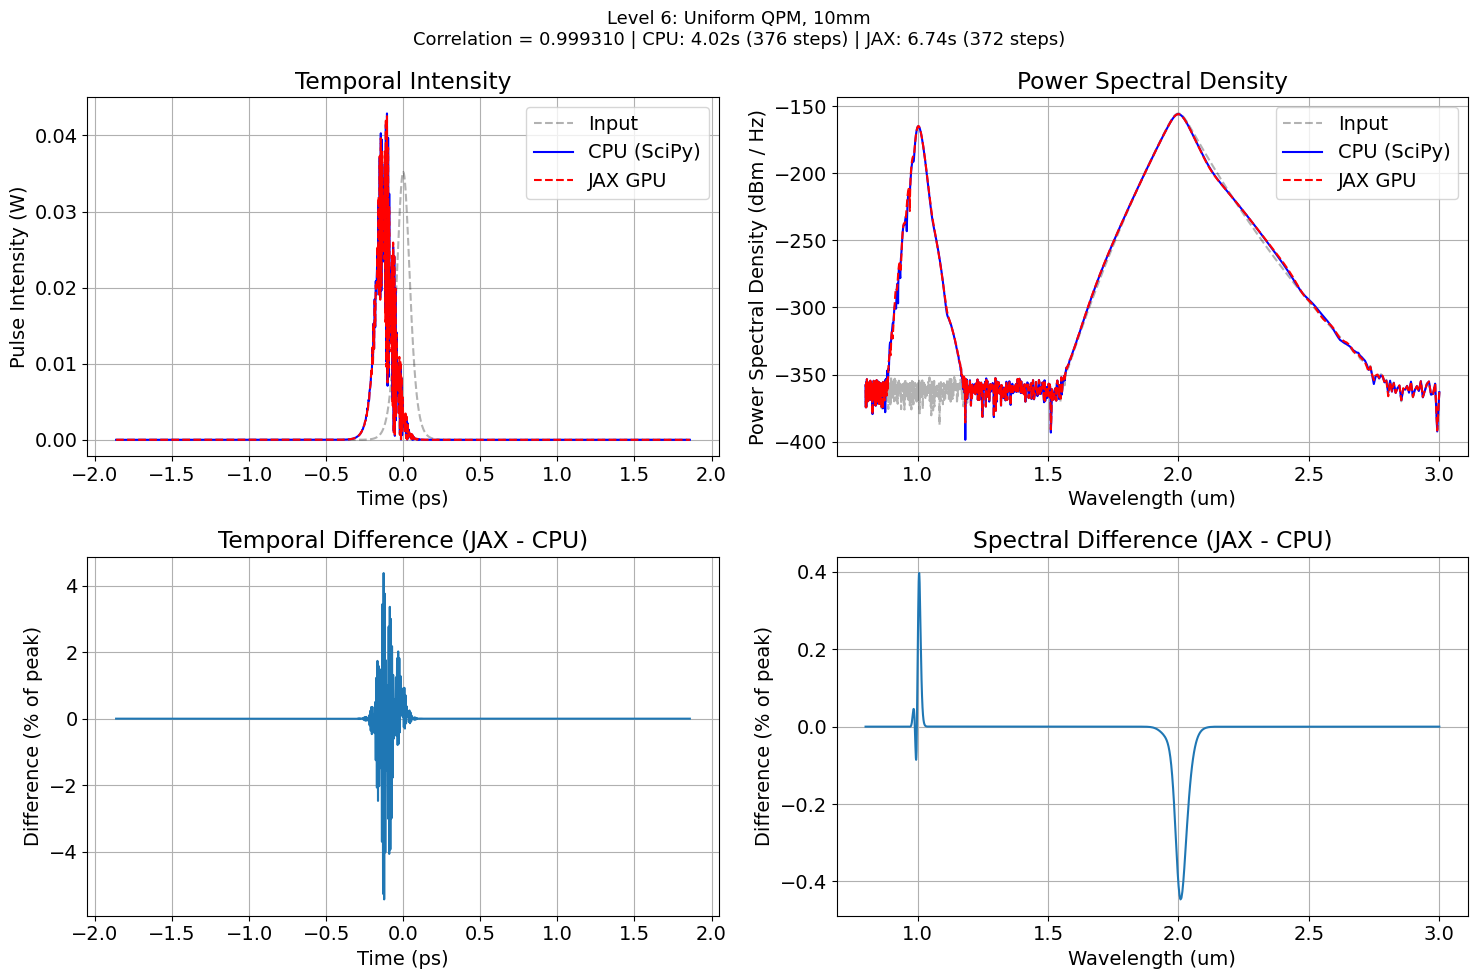

  Energy: in=0.0040  cpu=0.0040  jax=0.0040 pJ
  Speedup: 0.6x



In [9]:
wg = make_waveguide(L=10*mm, X0=1.1e-12)
run_and_compare('Level 6: Uniform QPM, 10mm', pump, wg);

## Level 7: SHG with loss

Nonlinear propagation combined with propagation loss.

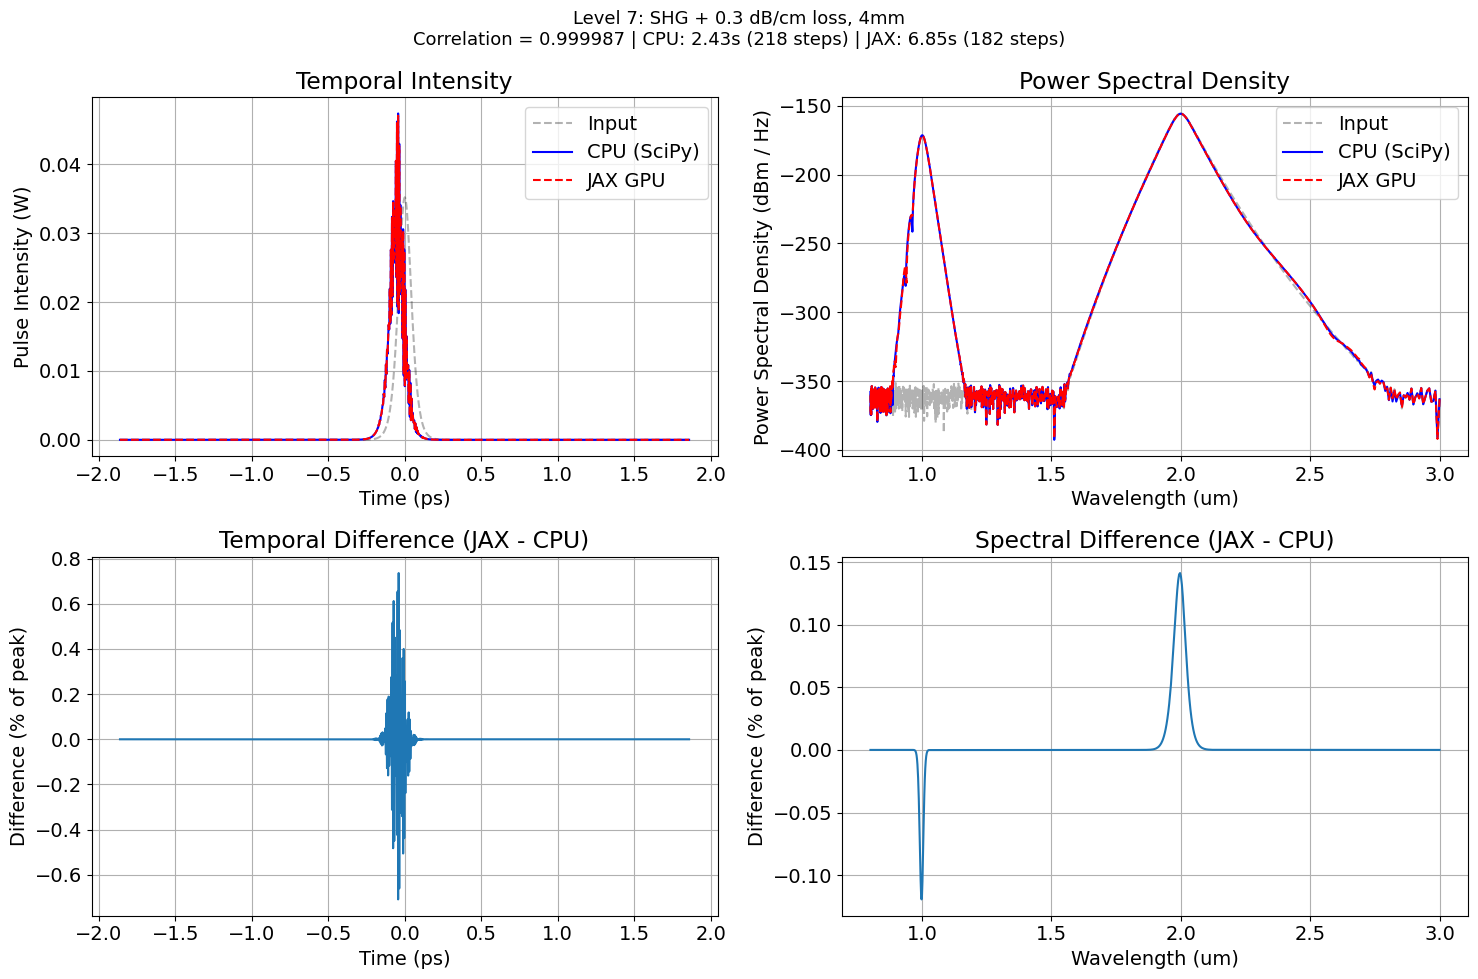

  Energy: in=0.0040  cpu=0.0039  jax=0.0039 pJ
  Speedup: 0.4x



In [10]:
alpha = util.absorption_coeff(0.3)
wg = make_waveguide(L=4*mm, X0=1.1e-12, alpha=alpha)
run_and_compare('Level 7: SHG + 0.3 dB/cm loss, 4mm', pump, wg);

## Level 8: Higher power (approaching pump depletion)

At higher powers, nonlinear conversion is stronger and the problem becomes
more sensitive to the exact step sequence. We expect the correlation to drop
but the physics (energy conservation, spectral features) should still agree.

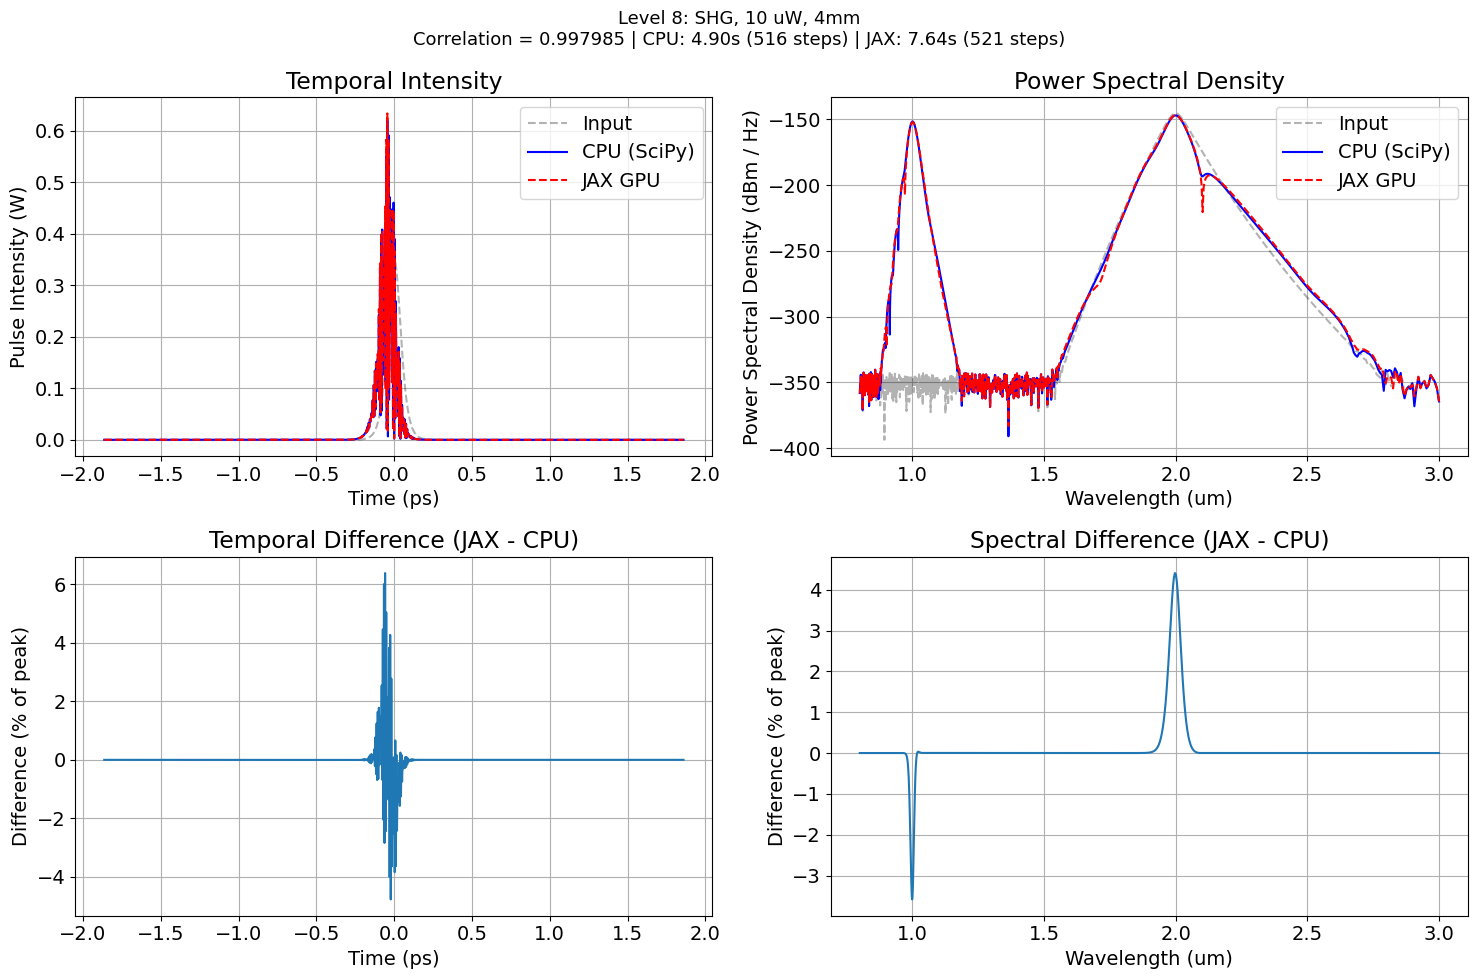

  Energy: in=0.0400  cpu=0.0398  jax=0.0399 pJ
  Speedup: 0.6x



In [11]:
pump_hi = pulses.sech_pulse(t, 100*fs, Pavg=10*uW, f_ref=f_ref, f0=c/(2*um),
                            Npwr_dB=200, frep=250*MHz)
wg = make_waveguide(L=4*mm, X0=1.1e-12)
run_and_compare('Level 8: SHG, 10 uW, 4mm', pump_hi, wg);

## Level 9: Parameter sweep — SHG efficiency vs crystal length

A standard design task: how does conversion efficiency depend on crystal
length?  In the undepleted-pump regime, SHG power scales as L$^2$.  At
higher conversion, back-conversion and walk-off cause the efficiency to
roll over.

We use N=2^12 here (broadband grid spanning 500nm to 5um) because the
JAX GPU advantage only manifests when the per-step FFTs are large enough
to dominate the host-device synchronization cost of the adaptive loop.
At N=2^10 the CPU is faster for these short crystals.

In [ ]:
from IPython.display import display
from snow import nlo_jax

# Broadband grid for the sweep: N=2^12
N_sweep = 2**12
f_max_s, f_min_s = c/(500*nm), c/(5*um)
BW_s = f_max_s - f_min_s
dt_s = 1/BW_s
t_s = -N_sweep/(2*BW_s) + np.arange(0, N_sweep/BW_s, step=dt_s)
f_ref_s = (f_max_s + f_min_s)/2

# Sweep parameters
L_max = 15*mm
L_values = np.arange(1, 16) * mm
pump_sweep = pulses.sech_pulse(t_s, 100*fs, Pavg=1*uW, f_ref=f_ref_s,
                               f0=c/(2*um), Npwr_dB=200, frep=250*MHz)
E_in = pump_sweep.energy_td()

# Build waveguide for max L (defines the poling function)
wg_sweep = make_waveguide(L=L_max, X0=1.1e-12)
v_ref_s = 1/wg_sweep.beta1(1*um)

# Pre-build poling table ONCE for max L — ensures consistent sampling
# across all sweep points and avoids JAX recompilation
Omega_s = pump_sweep.Omega
omega_abs_s = 2*pi*pump_sweep.f0 + Omega_s
def k_sweep(z):
    return wg_sweep.poling(z) * 1.1e-12 * omega_abs_s / 4

ptable = nlo_jax.build_poling_table(k_sweep, L_max, 0, N_sweep)
print(f'Poling table: {len(ptable[1])} samples over {L_max/mm:.0f} mm (built once)')

# Storage
eff_cpu = []; eff_jax = []
t_cpu_list = []; t_jax_list = []

# Create figure
fig_sweep, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)
line_cpu, = ax1.plot([], [], 'bo-', label='CPU (SciPy)', markersize=6)
line_jax, = ax1.plot([], [], 'rs--', label='JAX GPU', markersize=6)
ax1.set_xlabel('Crystal length (mm)'); ax1.set_ylabel('SH conversion efficiency')
ax1.set_title(f'SHG Efficiency vs Crystal Length (N={N_sweep})')
ax1.legend(); ax1.grid(True); ax1.set_xlim(0, 16)
ax2.set_xlabel('Crystal length (mm)'); ax2.set_ylabel('Wall time (s)')
ax2.set_title('Computation Time per Point'); ax2.grid(True, axis='y')
fig_handle = display(fig_sweep, display_id=True)

for i, L_val in enumerate(L_values):
    wg_s = make_waveguide(L=L_val, X0=1.1e-12)

    # CPU
    t0 = time.perf_counter()
    out_c, _ = wg_s.propagate_NEE(pump_sweep, v_ref=v_ref_s, verbose=False, backend='scipy')
    dt_cpu = time.perf_counter() - t0

    # JAX — reuse the pre-built poling table
    t0 = time.perf_counter()
    out_j, _ = wg_s.propagate_NEE(pump_sweep, v_ref=v_ref_s, verbose=False,
                                  backend='jax', poling_table=ptable)
    dt_jax = time.perf_counter() - t0

    # SH efficiency: filter around 1 um
    sh_cpu = out_c.apply_filter(c/(1*um), 50*THz)
    sh_jax = out_j.apply_filter(c/(1*um), 50*THz)
    eff_cpu.append(sh_cpu.energy_td() / E_in)
    eff_jax.append(sh_jax.energy_td() / E_in)
    t_cpu_list.append(dt_cpu)
    t_jax_list.append(dt_jax)

    # Update plots
    L_mm = [l/mm for l in L_values[:i+1]]
    line_cpu.set_data(L_mm, eff_cpu)
    line_jax.set_data(L_mm, eff_jax)
    ax1.relim(); ax1.autoscale_view()

    ax2.clear()
    x_bar = np.array(L_mm); w = 0.3
    ax2.bar(x_bar - w/2, t_cpu_list, w, label='CPU', color='steelblue')
    ax2.bar(x_bar + w/2, t_jax_list, w, label='JAX', color='indianred')
    ax2.set_xlabel('Crystal length (mm)'); ax2.set_ylabel('Wall time (s)')
    ax2.set_title('Computation Time per Point')
    ax2.legend(); ax2.grid(True, axis='y')

    fig_handle.update(fig_sweep)
    print(f'  L={L_val/mm:2.0f}mm: CPU={dt_cpu:.1f}s  JAX={dt_jax:.1f}s  '
          f'eff_cpu={eff_cpu[-1]:.4e}  eff_jax={eff_jax[-1]:.4e}')

total_cpu = sum(t_cpu_list); total_jax = sum(t_jax_list)
print(f'\n  Total: CPU={total_cpu:.1f}s  JAX={total_jax:.1f}s  '
      f'Speedup={total_cpu/total_jax:.1f}x over {len(L_values)} points')

## Level 10: Broadband simulation (N=2^12)

Levels 1-8 used N=2^10 (1024 points), where the CPU is fast and JAX pays
compilation overhead.  Real broadband simulations -- spanning multiple octaves
for supercontinuum or OPA -- need N=2^12 to 2^16.

Here we use N=2^12 with a 10mm crystal.  At this grid size, the CPU FFTs
become the bottleneck and JAX wins convincingly.

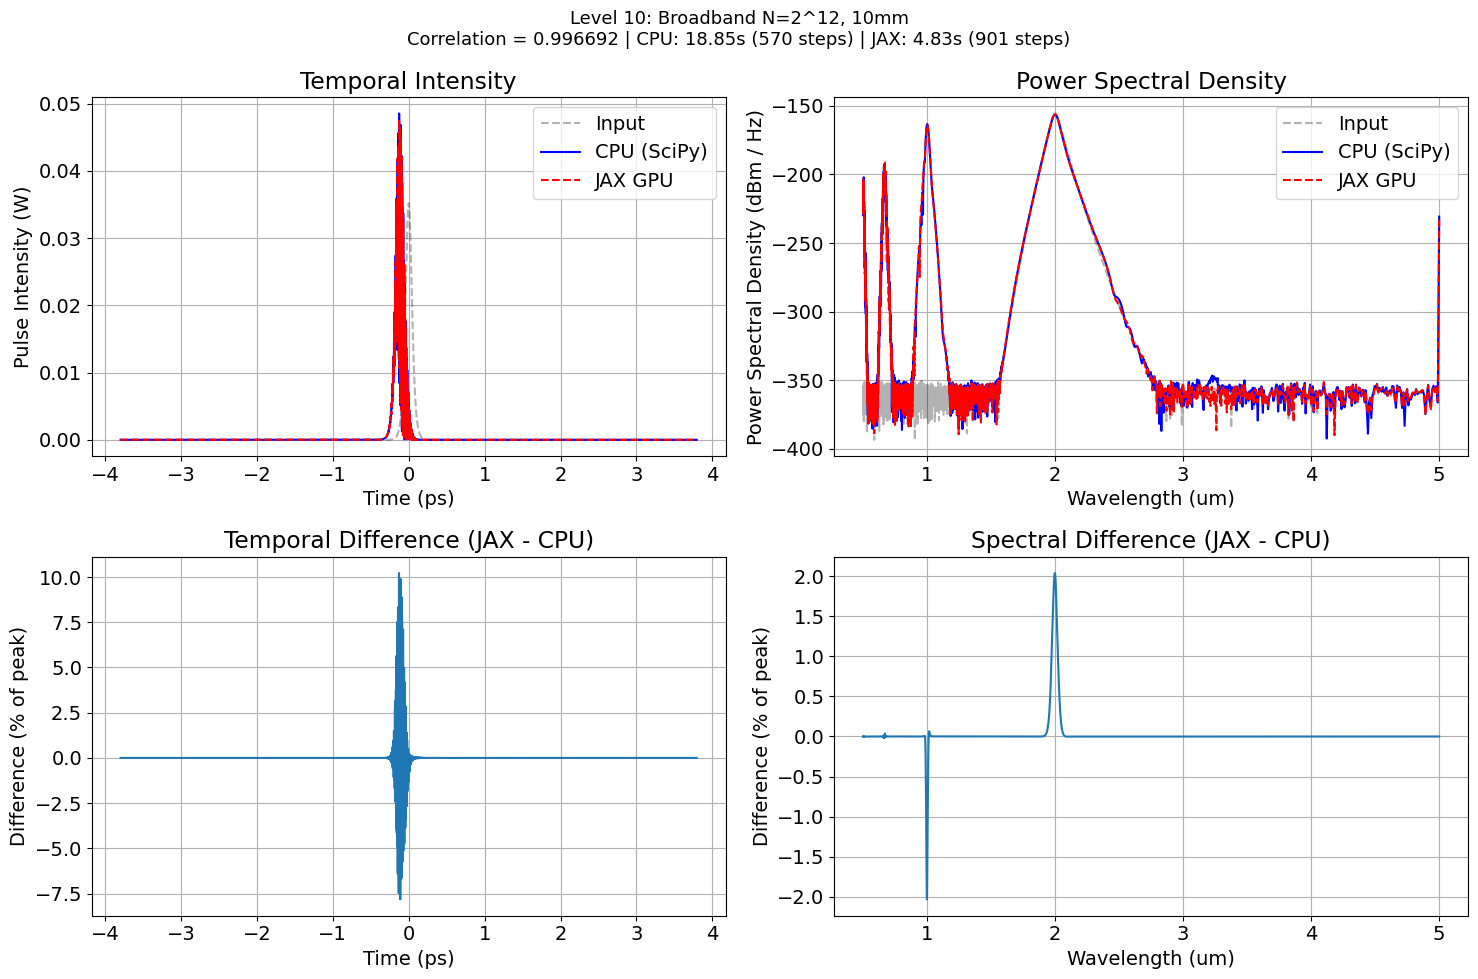

  Energy: in=0.0040  cpu=0.0040  jax=0.0040 pJ
  Speedup: 3.9x



In [13]:
# Broadband grid: 500nm to 5um, N=2^12
N10 = 2**12
f_max10, f_min10 = c/(500*nm), c/(5*um)
BW10 = f_max10 - f_min10
dt10 = 1/BW10
t10 = -N10/(2*BW10) + np.arange(0, N10/BW10, step=dt10)
f_ref10 = (f_max10 + f_min10)/2
f_abs10 = fftfreq(N10, dt10) + f_ref10

pump10 = pulses.sech_pulse(t10, 100*fs, Pavg=1*uW, f_ref=f_ref10, f0=c/(2*um),
                           Npwr_dB=200, frep=250*MHz)
wg10 = make_waveguide(L=10*mm, X0=1.1e-12)
v_ref10 = 1/wg10.beta1(1*um)

# Use broadband grid for plotting
_f_abs_save = f_abs
f_abs = f_abs10
run_and_compare('Level 10: Broadband N=2^12, 10mm', pump10, wg10, v_ref=v_ref10)
f_abs = _f_abs_save

## Summary

The JAX GPU solver reproduces the original SciPy CPU solver across the full
range of linear, dispersive, lossy, and nonlinear chi(2) physics, including
uniform, chirped, and apodized poling patterns.

**Validation** (Levels 1-8): differences are sub-percent for all cases up to
moderate nonlinearity.  At high conversion efficiency, both solvers remain
physically valid but diverge in detail due to adaptive step sensitivity.

**Performance** (Levels 9-10): JAX compilation is a one-time cost per grid size
(~3-6s).  For parameter sweeps, this is amortized over many runs.  For larger
grids (N=2^12+), the GPU wins convincingly even on a single run.